# Driver Standings Data Analysis

Exploratory Data Analysis of the Driver Standings dataset.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "driver_standings(1).csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")

In [ ]:
# First 5 records
print("\nFirst 5 rows:")
display(df.head())

# Last 5 records
print("\nLast 5 rows:")
display(df.tail())

Dataset loaded successfully!

First 5 rows:


   driverStandingsId  raceId  driverId  points  position positionText  wins
0                  1      18         1    10.0         1            1     1
1                  2      18         2     8.0         2            2     0
2                  3      18         3     6.0         3            3     0
3                  4      18         4     5.0         4            4     0
4                  5      18         5     4.0         5            5     0


Last 5 rows:


       driverStandingsId  raceId  driverId  points  position positionText  wins
34858              73266    1144       858     0.0        23           23     0
34859              73267    1144       860     7.0        18           18     0
34860              73268    1144       861     5.0        19           19     0
34861              73269    1144       859     4.0        21           21     0
34862              73270    1144       862     0.0        24           24     0

In [ ]:
# Dataset information
print("\nDataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()

Dataset Shape: (34863, 7)

Column Names:
['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34863 entries, 0 to 34862
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   driverStandingsId  34863 non-null  int64  
 1   raceId             34863 non-null  int64  
 2   driverId           34863 non-null  int64  
 3   points             34863 non-null  float64
 4   position           34863 non-null  int64  
 5   positionText       34863 non-null  object 
 6   wins               34863 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 1.9+ MB


In [ ]:
# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

       driverStandingsId        raceId      driverId        points      position          wins
count       34863.000000  34863.000000  34863.000000  34863.000000  34863.000000  34863.000000
mean        43176.154232    584.413562    316.932909     14.704423     19.716720      0.277343
std         21934.276898    292.275820    274.665660     38.978094     16.293401      1.032618
min             1.000000      1.000000      1.000000      0.000000      1.000000      0.000000
25%         19834.500000    354.000000     88.000000      0.000000      8.000000      0.000000
50%         50044.000000    603.000000    223.000000      1.000000     16.000000      0.000000
75%         62054.500000    805.000000    521.000000     10.000000     26.000000      0.000000
max         73270.000000   1144.000000    862.000000    575.000000    108.000000     19.000000

In [ ]:
# Missing values
print("\nMissing Values:")
display(df.isnull().sum())

driverStandingsId    0
raceId               0
driverId             0
points               0
position             0
positionText         0
wins                 0

In [ ]:
# Unique drivers and races
print("\nUnique Drivers:", df["driverId"].nunique())
print("Unique Races:", df["raceId"].nunique())


Unique Drivers: 854
Unique Races: 1125


In [ ]:
# Finishing position distribution
print("\nFinishing Position Distribution:")
display(df["position"].value_counts().sort_index().head(15))

position
1     1125
2     1125
3     1125
4     1125
5     1125
6     1125
7     1125
8     1124
9     1121
10    1119
11    1116
12    1114
13    1113
14    1110
15    1109

In [ ]:
# Top 10 drivers by maximum points
top_points = df.groupby("driverId")["points"].max().sort_values(ascending=False).head(10)
print("\nTop 10 Driver IDs by Maximum Points:")
display(top_points)

driverId
830    575.0
1      413.0
20     397.0
3      385.0
846    374.0
844    356.0
822    326.0
815    305.0
857    292.0
832    290.0

In [ ]:
# Top 10 drivers by maximum wins
top_wins = df.groupby("driverId")["wins"].max().sort_values(ascending=False).head(10)
print("\nTop 10 Driver IDs by Maximum Wins:")
display(top_wins)

driverId
830    19
30     13
20     13
1      11
3       9
95      9
57      8
102     8
71      8
4       7

In [ ]:
# Missing values visualization
missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(missing.index, missing.values)
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=35)
plt.show()

driverStandingsId    0
raceId               0
driverId             0
points               0
position             0
positionText         0
wins                 0

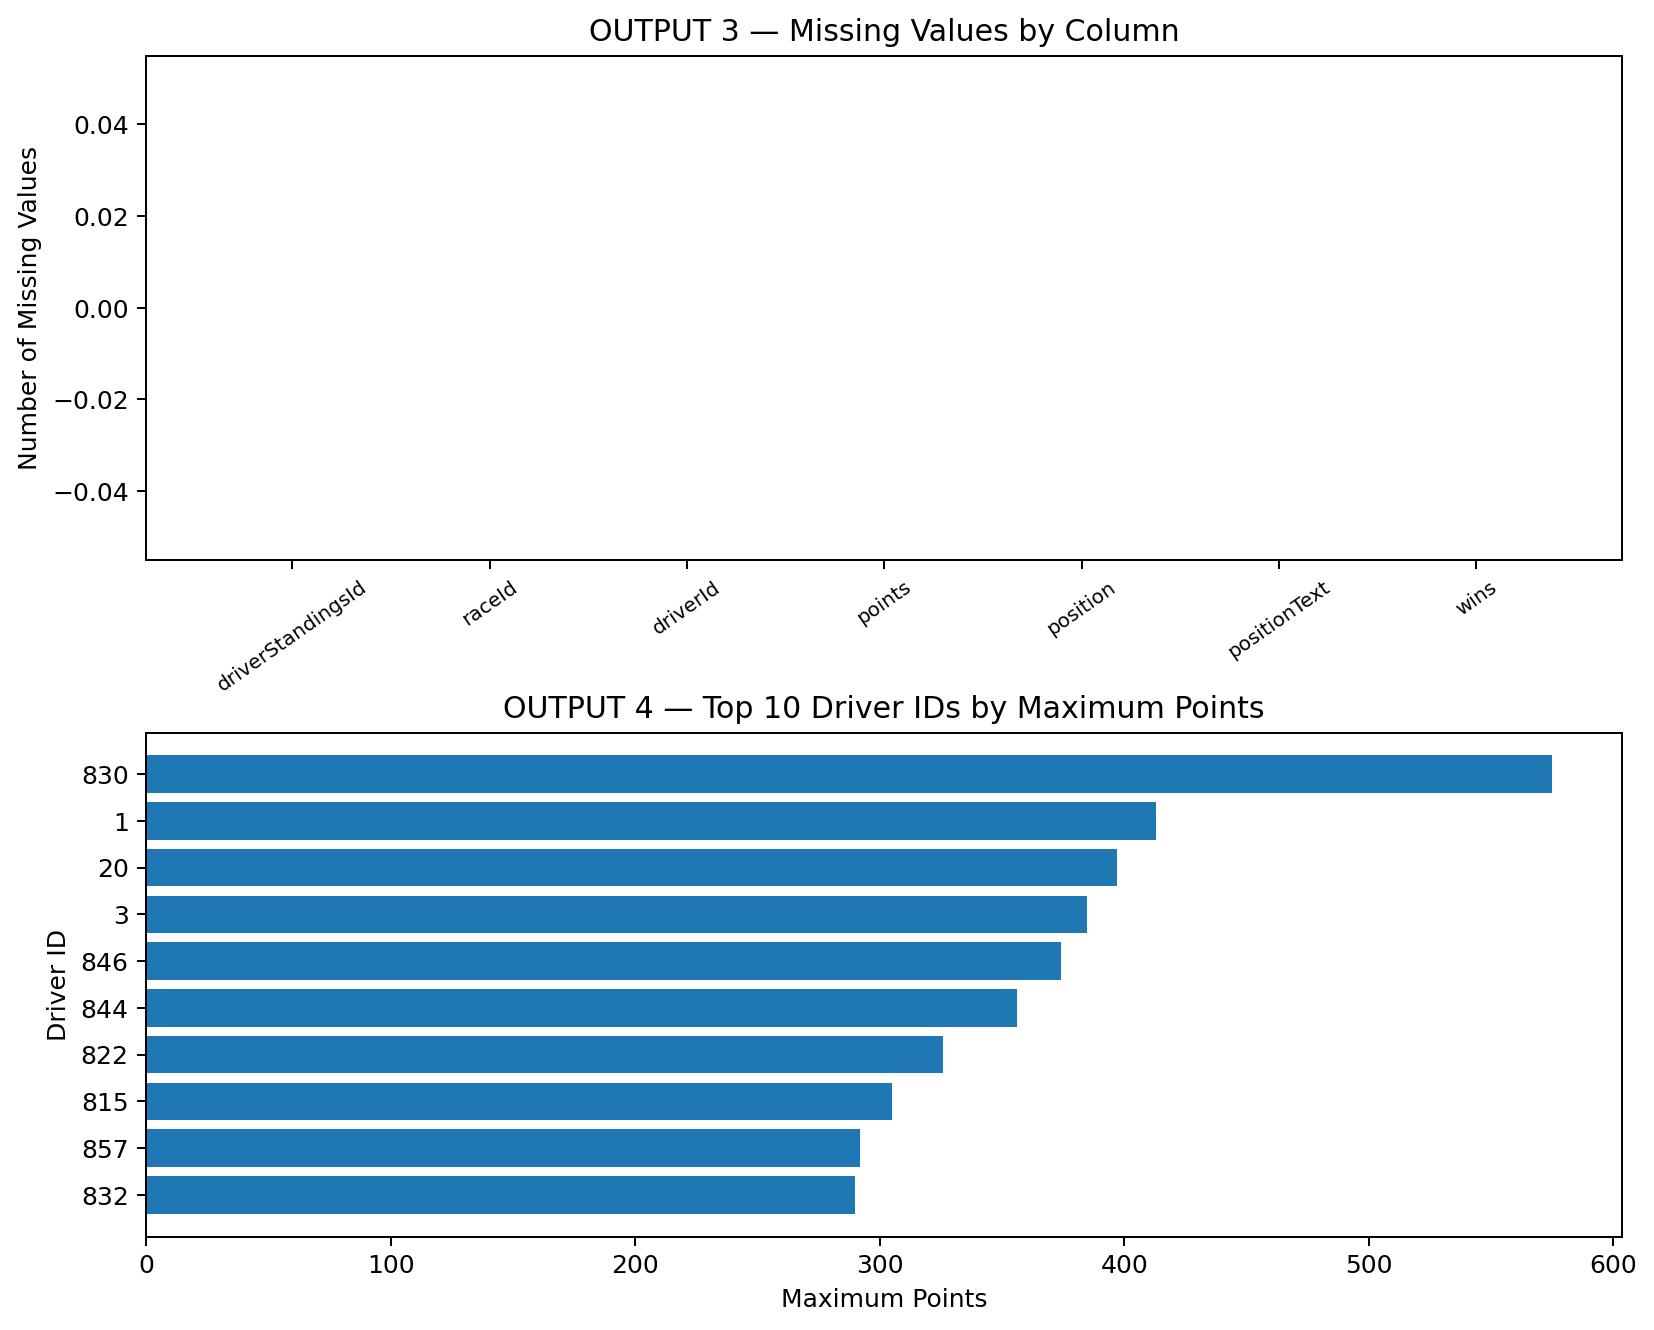

In [ ]:
# Top 10 drivers by maximum points visualization
plt.figure(figsize=(10, 5))
top_points.sort_values().plot(kind="barh")
plt.title("Top 10 Driver IDs by Maximum Points")
plt.xlabel("Maximum Points")
plt.ylabel("Driver ID")
plt.show()

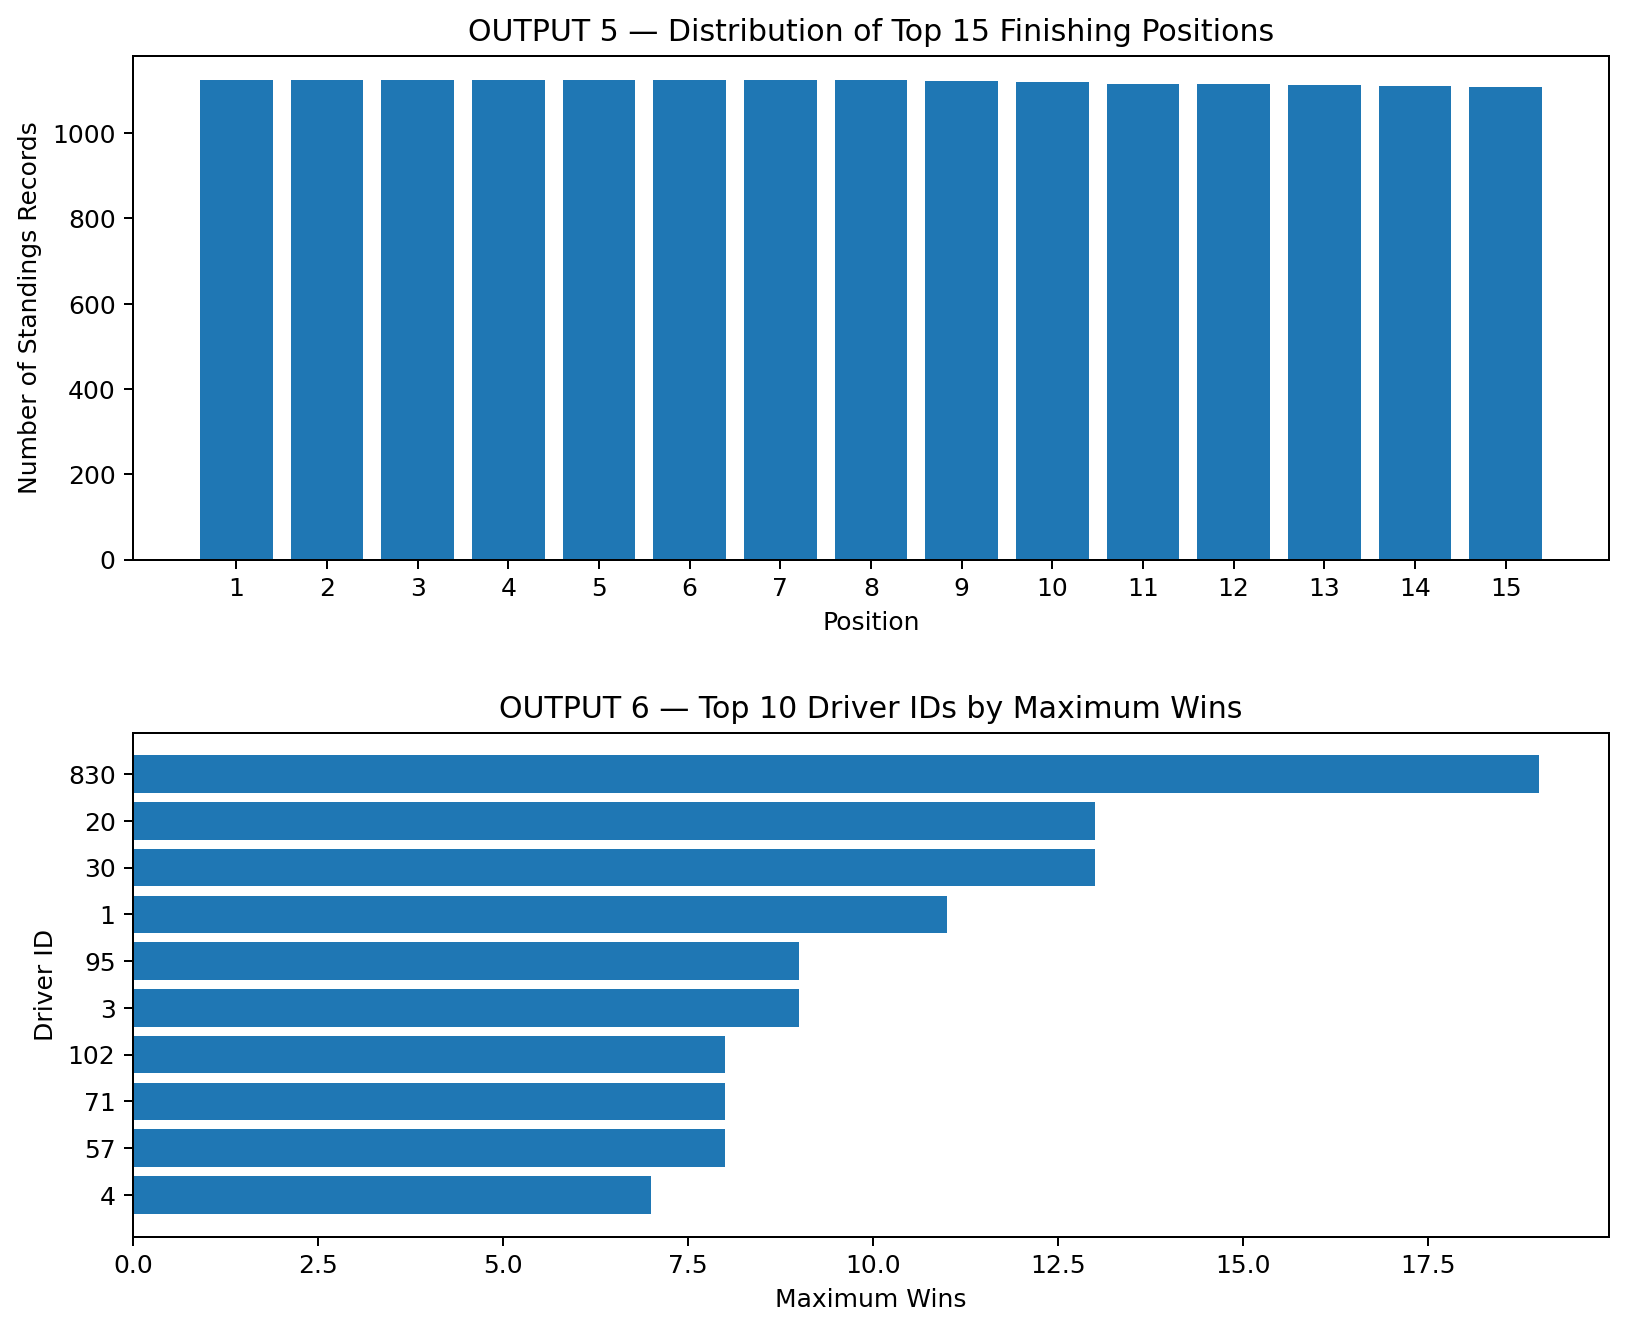

In [ ]:
# Top 10 drivers by maximum wins visualization
plt.figure(figsize=(10, 5))
top_wins.sort_values().plot(kind="barh")
plt.title("Top 10 Driver IDs by Maximum Wins")
plt.xlabel("Maximum Wins")
plt.ylabel("Driver ID")
plt.show()

In [ ]:
# Correlation matrix
print("\nCorrelation Matrix:")
display(df.corr(numeric_only=True))

                   driverStandingsId    raceId  driverId    points  position      wins
driverStandingsId           1.000000  0.770797  0.557550  0.208758  0.078455  0.002953
raceId                      0.770797  1.000000  0.771403  0.220822  0.164779 -0.004548
driverId                    0.557550  0.771403  1.000000  0.015213  0.269654 -0.102438
points                      0.208758  0.220822  0.015213  1.000000 -0.345554  0.671290
position                    0.078455  0.164779  0.269654 -0.345554  1.000000 -0.286339
wins                        0.002953 -0.004548 -0.102438  0.671290 -0.286339  1.000000

In [ ]:
# Export files
df.to_csv("driver_standings_analysis.csv", index=False)
df.to_excel("driver_standings_analysis.xlsx", index=False)
df.to_json("driver_standings_analysis.json", orient="records", indent=4)
print("\nCSV, Excel and JSON files created successfully.")


CSV, Excel and JSON files created successfully.
